# 02 · CTC 추론: 프레임별 예측에서 텍스트로
**목표:** argmax → 연속 반복 병합 → blank 제거 → 텍스트 복원을 관찰한다.

이 모델은 문자 기반 `WAV2VEC2_ASR_BASE_960H`입니다.
01번에서 만든 BPE를 사용하지 않습니다. CTC는 문자 또는 서브워드에 적용할 수 있습니다.
Greedy, Prefix Beam Search, 작은 문자 LM의 Shallow Fusion/Rescoring을 다룹니다.

In [ ]:
# 새 Colab 세션에서 가장 먼저 실행하세요. 설치는 최초 1회 수 분 걸릴 수 있습니다.
# TorchAudio 2.9 이후 바뀐 API를 피하기 위해 이 수업은 2.8.0으로 고정합니다.
import sys, subprocess, importlib.metadata as metadata
import shutil
packages = {'torch': '2.8.0', 'torchaudio': '2.8.0', 'torchvision': '0.23.0'}
def installed_version(name):
    try:
        return metadata.version(name).split('+')[0]
    except metadata.PackageNotFoundError:
        return None
needs_install = any(installed_version(k) != v for k, v in packages.items())
if needs_install:
    if any(k in sys.modules for k in packages):
        raise RuntimeError('PyTorch가 이미 로드되어 있습니다. 런타임 > 세션 다시 시작 후 이 셀부터 실행하세요.')
    # GPU 런타임은 CUDA 12.6 wheel, CPU 런타임은 CPU wheel을 사용합니다.
    gpu = shutil.which('nvidia-smi') is not None
    wheel_index = 'https://download.pytorch.org/whl/' + ('cu126' if gpu else 'cpu')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
        *[f'{k}=={v}' for k, v in packages.items()], '--index-url', wheel_index])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'numpy==2.2.6', 'pandas==2.2.3', 'matplotlib==3.10.3',
    'soundfile==0.13.1', 'sentencepiece==0.2.1', 'ipywidgets==8.1.7'])
print('설치 완료. 다음 셀을 실행하세요.')


In [ ]:
from pathlib import Path
import json, time, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torchaudio, soundfile as sf
from IPython.display import Audio, display
assert torch.__version__.split('+')[0] == '2.8.0', '설치 셀부터 다시 실행하세요.'
assert torchaudio.__version__.split('+')[0] == '2.8.0'
torch.manual_seed(0)
torch.set_num_threads(2)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__, '| torchaudio:', torchaudio.__version__, '| device:', DEVICE)
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': False})


torch: 2.8.0+cpu | torchaudio: 2.8.0+cpu | device: cpu


## 1. 직접 예측해 보기
각 행이 한 음성 프레임, 각 열이 출력 클래스인 교육용 확률표입니다.
**실제 음성 모델의 출력이 아니라, CTC 규칙을 설명하기 위해 만든 수치입니다.**
`a a blank a b b`의 최종 출력은 무엇일까요?


In [ ]:
def ctc_collapse(path, blank):
    """1) 인접 반복 병합, 2) blank 제거. 순서를 바꾸지 마세요."""
    merged = []
    previous = None
    for token in path:
        if token != previous:
            merged.append(token)
        previous = token  # blank도 previous에 기록해야 합니다.
    return [token for token in merged if token != blank]

assert ctc_collapse([1, 1], 0) == [1]
assert ctc_collapse([1, 0, 1], 0) == [1, 1]
assert ctc_collapse([0, 0], 0) == []


In [ ]:
toy_labels = ['<blank>', 'a', 'b']
toy_probs = torch.tensor([
    [.10, .80, .10], [.10, .80, .10], [.85, .10, .05],
    [.10, .80, .10], [.10, .10, .80], [.10, .10, .80],
])
assert torch.allclose(toy_probs.sum(-1), torch.ones(6))
toy_path = toy_probs.argmax(-1).tolist()
print('Raw   :', [toy_labels[i] for i in toy_path])
print('Result:', ''.join(toy_labels[i] for i in ctc_collapse(toy_path, 0)))
display(pd.DataFrame(toy_probs.numpy(), columns=toy_labels).rename_axis('frame'))
print('a a ->', ctc_collapse([1, 1], 0))
print('a blank a ->', ctc_collapse([1, 0, 1], 0))


Raw   : ['a', 'a', '<blank>', 'a', 'b', 'b']
Result: aab


,<blank>,a,b
frame,,,
0,0.10,0.8,0.10
1,0.10,0.8,0.10
2,0.85,0.1,0.05
3,0.10,0.8,0.10
4,0.10,0.1,0.80
5,0.10,0.1,0.80


a a -> [1]
a blank a -> [1, 1]


## 실제 음성 준비
기본값은 PyTorch 공식 튜토리얼에서 사용하는 짧은 영어 음성입니다.
**두 모델 모두 영어 모델**입니다. `USE_UPLOAD=True`이면 자신의 영어 WAV/FLAC 파일을 올릴 수 있습니다.
긴 파일은 시작 지점부터 최대 12초만 사용합니다. 기존 `harvard.wav`도 업로드할 수 있습니다.
재생 후 분석 구간을 확인하세요. 다운로드 실패 시 업로드 모드를 사용하세요.

샘플 출처: [VOiCES](https://github.com/iqtlabs/voices), CC BY 4.0.
파일: `Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav` (PyTorch 튜토리얼 배포본).


sample_voices.wav: 16000 Hz -> 16000 Hz, mono, 3.40 s


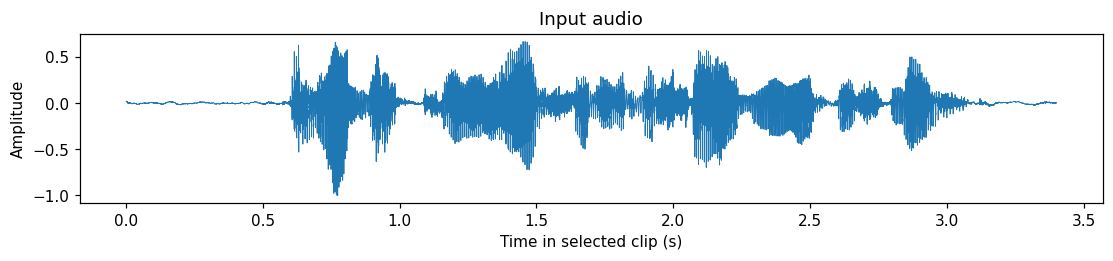

In [ ]:
USE_UPLOAD = False  #@param {type:"boolean"}
START_SECONDS = 0.0  #@param {type:"number"}
MAX_SECONDS = 12.0  #@param {type:"number"}
assert START_SECONDS >= 0 and 0.5 <= MAX_SECONDS <= 30
if USE_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError('WAV 또는 FLAC 파일 하나를 업로드하세요.')
    audio_path = Path(next(iter(uploaded)))
else:
    audio_path = Path('sample_voices.wav')
    url = ('https://download.pytorch.org/torchaudio/tutorial-assets/'
           'Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav')
    if not audio_path.exists():
        with urllib.request.urlopen(url, timeout=60) as r:
            audio_path.write_bytes(r.read())
samples, original_sr = sf.read(audio_path, dtype='float32', always_2d=True)
samples = samples.mean(axis=1)  # stereo -> mono
start = int(START_SECONDS * original_sr)
samples = samples[start:start + int(MAX_SECONDS * original_sr)]
if len(samples) < original_sr // 2:
    raise ValueError('선택 구간이 0.5초보다 짧습니다. 시작 지점을 바꾸세요.')
if not np.isfinite(samples).all() or np.max(np.abs(samples)) == 0:
    raise ValueError('유효한 음성 데이터가 없습니다.')
waveform = torch.from_numpy(samples.copy())
SAMPLE_RATE = 16000
if original_sr != SAMPLE_RATE:
    waveform = torchaudio.functional.resample(waveform, original_sr, SAMPLE_RATE)
duration = waveform.numel() / SAMPLE_RATE
print(f'{audio_path.name}: {original_sr} Hz -> {SAMPLE_RATE} Hz, mono, {duration:.2f} s')
display(Audio(waveform.numpy(), rate=SAMPLE_RATE))
fig, ax = plt.subplots(figsize=(12, 2))
ax.plot(np.arange(len(waveform))/SAMPLE_RATE, waveform.numpy(), lw=0.6)
ax.set(xlabel='Time in selected clip (s)', ylabel='Amplitude', title='Input audio')
plt.show()


## 2. 공개 모델의 실제 프레임별 분포

Encoder는 음성의 문맥을 볼 수 있습니다. CTC의 조건부 독립 가정은
**이전 출력 토큰을 다시 입력하지 않는다**는 점과 관련됩니다.
아래 모델은 전체 음성을 처리하며, 이 셀은 스트리밍 데모가 아닙니다.


In [ ]:
bundle = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H
assert bundle.sample_rate == SAMPLE_RATE
ctc_model = bundle.get_model().to(DEVICE).eval()
labels = list(bundle.get_labels())
BLANK = 0  # 이 bundle의 공식 label mapping: '-'가 blank, '|'가 단어 경계
assert labels[BLANK] == '-'
display(pd.DataFrame({'id': range(len(labels)), 'label': labels}))
started = time.perf_counter()
with torch.inference_mode():
    logits, _ = ctc_model(waveform[None].to(DEVICE))
    probs = logits[0].softmax(-1).cpu()
if DEVICE.type == 'cuda':
    torch.cuda.synchronize()
print('Inference seconds:', round(time.perf_counter()-started, 3))
print('Logits [B,T,V]:', tuple(logits.shape))
assert torch.allclose(probs.sum(-1), torch.ones(len(probs)), atol=1e-5)
raw_ids = probs.argmax(-1).tolist()
token_ids = ctc_collapse(raw_ids, BLANK)
transcript = ''.join(labels[i] for i in token_ids).replace('|', ' ').strip()
print('Raw first 100:', ' '.join('<blank>' if i == BLANK else labels[i] for i in raw_ids[:100]))
print('Transcript:', transcript)
print('Blank argmax fraction:', round(sum(i == BLANK for i in raw_ids)/len(raw_ids), 3))


Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960_asr_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960_asr_ls960.pth


100%|██████████| 360M/360M [00:01<00:00, 307MB/s]


,id,label
0,0,-
1,1,|
2,2,E
3,3,T
4,4,A
5,5,O
6,6,N
7,7,I
8,8,H
9,9,S


Inference seconds: 0.93
Logits [B,T,V]: (1, 169, 29)
Raw first 100: <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> <blank> I <blank> <blank> | | <blank> H <blank> A <blank> D <blank> | | T T H <blank> A T T | | <blank> <blank> C <blank> <blank> <blank> <blank> U <blank> R R <blank> <blank> I <blank> <blank> <blank> <blank> <blank> <blank> O O <blank> <blank> <blank> S <blank> <blank> <blank> I <blank> <blank> T <blank> <blank> Y Y | | | <blank> B <blank> <blank> E <blank> <blank>
Transcript: I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT
Blank argmax fraction: 0.592


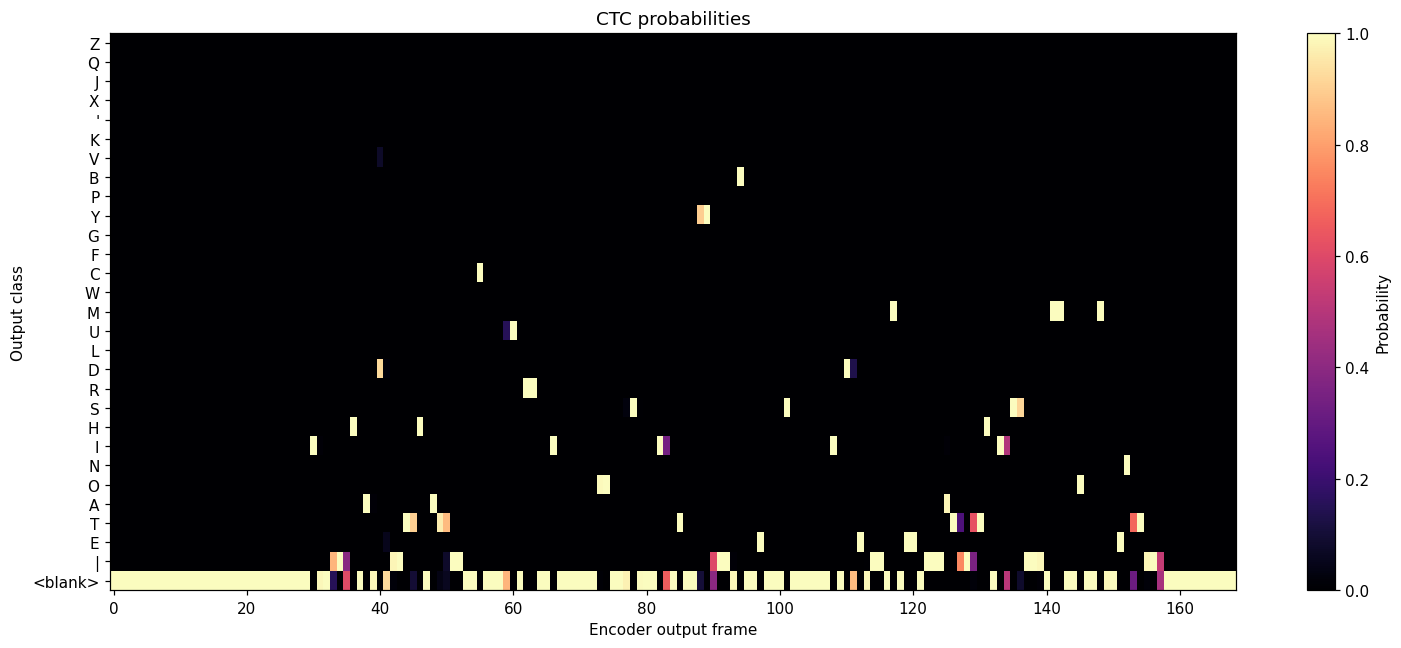

,frame,id,token,p_selected,p_blank
0,0,0,<blank>,1.0,1.0
1,1,0,<blank>,1.0,1.0
2,2,0,<blank>,1.0,1.0
3,3,0,<blank>,1.0,1.0
4,4,0,<blank>,1.0,1.0
5,5,0,<blank>,1.0,1.0
6,6,0,<blank>,1.0,1.0
7,7,0,<blank>,1.0,1.0
8,8,0,<blank>,1.0,1.0
9,9,0,<blank>,1.0,1.0


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(probs.T.numpy(), origin='lower', aspect='auto', vmin=0, vmax=1,
               interpolation='nearest', cmap='magma')
ax.set_yticks(range(len(labels)), ['<blank>' if i == BLANK else x for i, x in enumerate(labels)])
ax.set(xlabel='Encoder output frame', ylabel='Output class', title='CTC probabilities')
fig.colorbar(im, ax=ax, label='Probability')
plt.tight_layout(); plt.show()
# 전체 프레임별 표를 CSV로 보관합니다.
frame_table = pd.DataFrame({'frame': range(len(raw_ids)), 'id': raw_ids,
    'token': ['<blank>' if i == BLANK else labels[i] for i in raw_ids],
    'p_selected': probs.max(-1).values.numpy(), 'p_blank': probs[:, BLANK].numpy()})
result_dir = Path('ctc_results'); result_dir.mkdir(exist_ok=True)
frame_table.to_csv(result_dir/'frames.csv', index=False)
(result_dir/'transcript.txt').write_text(transcript, encoding='utf-8')
fig.savefig(result_dir/'probabilities.png', dpi=130, bbox_inches='tight')
display(frame_table.head(25))


## 4. Greedy와 Prefix Beam Search
Greedy는 가장 높은 **프레임별 경로**를 선택합니다. CTC에서는 서로 다른 경로가 같은
출력 문자열로 합쳐지므로, 가장 높은 경로와 가장 높은 문자열은 다를 수 있습니다.

Prefix beam search는 출력 접두사(prefix)별로 두 값을 따로 유지합니다.
- `pb`: blank로 끝나는 경로들의 확률 합
- `pnb`: 일반 토큰으로 끝나는 경로들의 확률 합

반복 문자 처리에 이 구분이 필요합니다. `a → a`는 같은 prefix `a`에 머물고,
`a → blank → a`는 prefix `aa`로 늘어납니다.
각 프레임에서 후보를 확장하고 동일 prefix를 합한 뒤 상위 B개만 남깁니다.
Beam pruning을 하면 확률 합은 근사치이며, B=1도 CTC Greedy와 항상 같지는 않습니다.
아래 구현은 작은 어휘를 위해 모든 클래스를 확장합니다. 큰 어휘용 고속 구현은 아닙니다.


In [ ]:
import math
from collections import defaultdict, Counter
from functools import lru_cache

def ctc_prefix_beam_search(log_probs, blank=0, beam_size=25,
                           lm=None, alpha=0.0, beta=0.0):
    """log_probs[T,V]. CTC 질량과 LM 점수를 분리하여 prefix를 순위화합니다."""
    lp = np.asarray(log_probs, dtype=np.float64)
    if lp.ndim != 2 or not 0 <= blank < lp.shape[1] or beam_size < 1:
        raise ValueError('T x V 배열, 올바른 blank ID, 양의 beam_size가 필요합니다.')
    if np.isnan(lp).any() or np.isposinf(lp).any():
        raise ValueError('NaN/+inf log probability는 허용하지 않습니다.')
    if not np.allclose(np.exp(lp).sum(axis=1), 1.0, atol=1e-5):
        raise ValueError('각 프레임의 확률 합은 1이어야 합니다.')
    if alpha != 0 and lm is None:
        raise ValueError('alpha != 0이면 LM을 전달하세요.')
    neginf = -float('inf')
    # prefix -> [log pb, log pnb]. 빈 경로의 확률은 1입니다.
    beams = {(): [0.0, neginf]}

    @lru_cache(maxsize=50000)
    def lm_score(prefix, final=False):
        return 0.0 if lm is None else lm.log_score(prefix, final=final)

    def rank(prefix, masses, final=False):
        acoustic = float(np.logaddexp(*masses))
        language = lm_score(prefix, final) if alpha else 0.0
        return acoustic + alpha * language + beta * len(prefix)

    history = []
    for t, frame in enumerate(lp):
        nxt = defaultdict(lambda: [neginf, neginf])
        for prefix, (pb, pnb) in beams.items():
            total = float(np.logaddexp(pb, pnb))
            # blank: prefix 유지. 이전 blank/non-blank 양쪽에서 도착 가능.
            if np.isfinite(frame[blank]):
                nxt[prefix][0] = float(np.logaddexp(nxt[prefix][0], total + frame[blank]))
            for token in range(lp.shape[1]):
                if token == blank or not np.isfinite(frame[token]):
                    continue
                extended = prefix + (token,)
                if prefix and token == prefix[-1]:
                    # 연속 동일 토큰은 collapse되어 기존 prefix에 머뭅니다.
                    nxt[prefix][1] = float(np.logaddexp(nxt[prefix][1], pnb + frame[token]))
                    # 동일 문자를 새로 추가하려면 직전 경로가 blank로 끝나야 합니다.
                    nxt[extended][1] = float(np.logaddexp(nxt[extended][1], pb + frame[token]))
                else:
                    nxt[extended][1] = float(np.logaddexp(nxt[extended][1], total + frame[token]))
        valid = [(p, masses) for p, masses in nxt.items()
                 if np.isfinite(np.logaddexp(*masses))]
        beams = dict(sorted(valid, key=lambda item: (-rank(*item), item[0]))[:beam_size])
        history.append([{'t': t, 'ids': p, 'log_pb': masses[0], 'log_pnb': masses[1],
                         'ctc_logp': float(np.logaddexp(*masses)),
                         'score': rank(p, masses)} for p, masses in beams.items()])
    results = []
    for prefix, masses in beams.items():
        acoustic = float(np.logaddexp(*masses))
        language = lm_score(prefix, True) if lm is not None else 0.0
        results.append({'ids': prefix, 'ctc_logp': acoustic, 'lm_logp': language,
                        'score': acoustic + alpha*language + beta*len(prefix)})
    results.sort(key=lambda r: (-r['score'], r['ids']))
    return results, history

def to_log_probs(p):
    p = np.asarray(p, dtype=float)
    with np.errstate(divide='ignore'):
        return np.log(p)  # zero probability -> -inf; epsilon으로 바꾸지 않습니다.


## 5. 언어모델(LM) 만들기와 Shallow Fusion
이번에는 외부 대형 모델 대신, **텍스트만으로 학습한 작은 문자 bigram LM**을 사용합니다.
P(다음 문자 | 직전 문자)를 세고 add-k smoothing으로 보지 못한 전이에도 확률을 줍니다.
이 LM은 문장 의미를 이해하지 않으며 단어 수준 LM이나 GPT가 아닙니다.

$$S(y)=\log P_{CTC}(y\mid x)+\alpha\log P_{LM}(y)+\beta |y|$$

- alpha: 언어모델 영향력 (0이면 음성 점수만 사용)
- beta: 출력 토큰 수에 대한 보너스. LM 때문에 짧은 출력을 선호하는 경향을 조절 (기본 0)
- 최종 후보에는 LM의 EOS 확률을 한 번 추가합니다. EOS는 CTC 출력 클래스가 아닙니다.

탐색 중 후보를 남길 때 위 점수를 사용하므로 **Shallow Fusion**입니다.
코드에서는 prefix 전체의 LM 점수를 캐시해 순위를 계산합니다. blank 또는 반복 경로가
같은 prefix에 머무르면 그 prefix의 LM 점수는 변하지 않습니다. 매 프레임 LM을 누적하지 않습니다.


In [ ]:
class CharBigramLM:
    def __init__(self, sentences, labels, blank=0, smoothing=0.5):
        if smoothing <= 0:
            raise ValueError('smoothing은 양수여야 합니다.')
        self.labels, self.blank, self.k = list(labels), blank, smoothing
        self.ids = {s: i for i, s in enumerate(labels) if i != blank}
        self.bos, self.eos = -1, -2  # LM 내부용, 음성 모델의 클래스가 아닙니다.
        self.outcomes = len(labels) - 1 + 1  # nonblank tokens + EOS
        self.counts, self.totals = Counter(), Counter()
        for text in sentences:
            text = ' '.join(text.upper().split())
            pieces = list(text.replace(' ', '|'))
            unknown = set(pieces) - set(self.ids)
            if unknown:
                raise ValueError(f'LM corpus에 모델 어휘 밖 문자 존재: {unknown}')
            seq = [self.bos] + [self.ids[c] for c in pieces] + [self.eos]
            for prev, token in zip(seq, seq[1:]):
                self.counts[prev, token] += 1
                self.totals[prev] += 1

    def log_next(self, previous, token):
        return math.log((self.counts[previous, token] + self.k) /
                        (self.totals[previous] + self.k*self.outcomes))

    def log_score(self, prefix, final=False):
        previous, score = self.bos, 0.0
        for token in prefix:
            if token == self.blank:
                raise ValueError('LM에는 blank를 입력하지 않습니다.')
            score += self.log_next(previous, token)
            previous = token
        if final:
            score += self.log_next(previous, self.eos)
        return score


In [ ]:
# 의도적으로 COT와 CAT가 애매한 합성 음성 분포를 만듭니다. 실제 음성 출력이 아닙니다.
lm_demo_labels = ['<blank>', 'C', 'A', 'O', 'T']
ambiguous = np.array([
    [0, 1, 0, 0, 0], [1, 0, 0, 0, 0],
    [0, 0, .45, .55, 0], [1, 0, 0, 0, 0], [0, 0, 0, 0, 1],
])
# CAT가 더 흔한 작은 코퍼스를 의도적으로 구성했습니다.
demo_lm = CharBigramLM(['CAT']*20 + ['COT'], lm_demo_labels, smoothing=.5)
def compare_alpha(alpha=0.0):
    candidates, _ = ctc_prefix_beam_search(to_log_probs(ambiguous), beam_size=10,
                                           lm=demo_lm, alpha=alpha)
    display(pd.DataFrame([{'text': ''.join(lm_demo_labels[i] for i in r['ids']),
        'CTC logp': r['ctc_logp'], 'LM logp': r['lm_logp'], 'combined': r['score']}
        for r in candidates]))
from ipywidgets import FloatSlider
compare_alpha(0.0)
compare_alpha(1.0)
interact(compare_alpha, alpha=FloatSlider(min=0, max=2, step=.1, value=0,
                                          continuous_update=False))


,text,CTC logp,LM logp,combined
0,COT,-0.597837,-3.776728,-0.597837
1,CAT,-0.798508,-0.407561,-0.798508


,text,CTC logp,LM logp,combined
0,CAT,-0.798508,-0.407561,-1.206069
1,COT,-0.597837,-3.776728,-4.374565


interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='alpha', max=2.0), Output())…

<function __main__.compare_alpha(alpha=0.0)>

## 6. 실제 음성 출력에 세 가지 디코딩 적용
앞에서 계산한 동일한 logits에 Greedy / Beam / Beam+LM을 적용합니다.
음성 모델을 다시 실행하거나 학습하지 않습니다.
아래 LM 코퍼스는 별도로 만든 짧은 예문입니다. 테스트 음성의 정답이나 인식 결과를
LM 학습에 추가하지 않습니다. 이 작은 LM은 **결합 원리용**이며 정확도 개선을 보장하지 않습니다.
세 결과가 같을 수도 있고 LM을 켜면 더 나빠질 수도 있습니다.


In [ ]:
LM_CORPUS = [
    'WE READ BOOKS EVERY DAY', 'THE CAT IS SLEEPING ON THE CHAIR',
    'THE DOG IS PLAYING IN THE GARDEN', 'PLEASE OPEN THE DOOR',
    'I HAVE A QUESTION', 'SHE HAS A NEW BOOK', 'LET US GO TO THE MOVIE',
    'THERE ARE TWO CATS IN THE ROOM', 'THIS BOOK IS TOO HEAVY',
    'WE ARE LEARNING SPEECH RECOGNITION', 'THE WEATHER IS NICE TODAY',
    'HE WENT TO SCHOOL EARLY', 'THE STUDENTS ARE LISTENING TO THE TEACHER',
    'THE TRAIN ARRIVES IN THE MORNING', 'PLEASE READ THE NEXT SENTENCE',
]
real_lm = CharBigramLM(LM_CORPUS, labels, blank=BLANK, smoothing=.5)
BEAM_SIZE = 25  #@param {type:"integer"}
LM_ALPHA = 0.3  #@param {type:"number"}
TOKEN_BONUS = 0.0  #@param {type:"number"}
assert 1 <= BEAM_SIZE <= 100 and LM_ALPHA >= 0

ctc_log_probs = logits[0].log_softmax(-1).cpu().numpy()
def ids_to_text(ids):
    return ''.join(labels[i] for i in ids).replace('|', ' ').strip()
started = time.perf_counter()
beam_results, _ = ctc_prefix_beam_search(ctc_log_probs, BLANK, BEAM_SIZE)
beam_seconds = time.perf_counter() - started
started = time.perf_counter()
fused_results, _ = ctc_prefix_beam_search(ctc_log_probs, BLANK, BEAM_SIZE,
                                         real_lm, LM_ALPHA, TOKEN_BONUS)
fusion_seconds = time.perf_counter() - started
comparison = pd.DataFrame([
    {'method': 'Greedy', 'transcript': transcript},
    {'method': 'Prefix beam', 'transcript': ids_to_text(beam_results[0]['ids'])},
    {'method': 'Prefix beam + LM', 'transcript': ids_to_text(fused_results[0]['ids'])},
])
display(comparison)
print(f'Beam decoding: {beam_seconds:.2f}s | Beam+LM decoding: {fusion_seconds:.2f}s')
def candidate_table(results, n=5):
    return pd.DataFrame([{'text': ids_to_text(r['ids']), 'CTC logp (approx)': r['ctc_logp'],
        'LM logp': r['lm_logp'], 'combined score': r['score']} for r in results[:n]])
display(candidate_table(fused_results))
comparison.to_csv(result_dir/'decoding_comparison.csv', index=False, encoding='utf-8-sig')
candidate_table(fused_results, BEAM_SIZE).to_csv(result_dir/'beam_lm_candidates.csv',
                                               index=False, encoding='utf-8-sig')


,method,transcript
0,Greedy,I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT
1,Prefix beam,I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT
2,Prefix beam + LM,I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT


Beam decoding: 1.36s | Beam+LM decoding: 1.56s


,text,CTC logp (approx),LM logp,combined score
0,I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT,-0.167698,-132.995641,-40.066391
1,I HAV THAT CURIOSITY BESIDE ME AT THIS MOMENT,-2.697901,-134.461978,-43.036495
2,I HADE THAT CURIOSITY BESIDE ME AT THIS MOMENT,-3.077684,-134.040549,-43.289849
3,I HAD THAT CURIOSITY BESIDE ME IT THIS MOMENT,-4.373055,-133.647878,-44.467419
4,I HAD THA CURIOSITY BESIDE ME AT THIS MOMENT,-5.429710,-130.934218,-44.709976


## 7. 선택 실험: Rescoring과 Shallow Fusion 비교
Rescoring은 음성 점수로 이미 얻은 N-best 후보만 다시 정렬합니다.
Shallow Fusion은 후보를 잘라내기 전부터 LM을 사용합니다.
아래는 **같은 후보 집합**을 재정렬하는 것이므로, 탈락한 문장을 새로 만들 수 없습니다.
음성 점수는 beam pruning으로 일부 경로가 빠진 근사값입니다.


In [ ]:
rescored = []
for r in beam_results:
    lm_value = real_lm.log_score(r['ids'], final=True)
    rescored.append(dict(r, lm_logp=lm_value,
        score=r['ctc_logp'] + LM_ALPHA*lm_value + TOKEN_BONUS*len(r['ids'])))
rescored.sort(key=lambda r: (-r['score'], r['ids']))
display(candidate_table(rescored))
print('Rescoring:', ids_to_text(rescored[0]['ids']))
print('Shallow fusion:', ids_to_text(fused_results[0]['ids']))
candidate_table(rescored, BEAM_SIZE).to_csv(result_dir/'rescoring_candidates.csv',
                                          index=False, encoding='utf-8-sig')


,text,CTC logp (approx),LM logp,combined score
0,I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT,-0.167698,-132.995641,-40.066390
1,I HAV THAT CURIOSITY BESIDE ME AT THIS MOMENT,-2.697945,-134.461978,-43.036539
2,I HADE THAT CURIOSITY BESIDE ME AT THIS MOMENT,-3.077686,-134.040549,-43.289851
3,I HAD THAT CURIOSITY BESIDE ME IT THIS MOMENT,-4.373054,-133.647878,-44.467418
4,I HAD THA CURIOSITY BESIDE ME AT THIS MOMENT,-5.433229,-130.934218,-44.713494


Rescoring: I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT
Shallow fusion: I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT


## 확인 질문
1. 가장 높은 프레임별 경로를 골라도 가장 높은 문자열을 얻지 못하는 이유는?
2. Prefix별로 blank/non-blank 확률을 따로 저장해야 하는 이유는?
3. blank가 나올 때마다 LM 점수를 더하면 어떤 문제가 생길까요?
4. alpha=0 / 0.3 / 1.0에서 실제 결과를 비교해 보세요. LM은 항상 유리한가요?
5. Rescoring에서 후보 목록 밖의 문장을 선택할 수 있나요?

<details><summary>교사용 해설</summary>
1. 서로 다른 정렬 경로의 확률이 같은 문자열로 합쳐집니다.
2. 동일 토큰이 반복될 때 새 문자 추가와 기존 문자 반복을 구별하기 위해서입니다.
3. 동일한 출력 문자열에도 blank의 수/위치에 따라 다른 언어 점수가 적용됩니다.
4. LM의 코퍼스와 강도에 따라 좋아지거나 나빠질 수 있으며, 결과가 같을 수도 있습니다.
5. 불가능합니다. Shallow Fusion은 탐색 중 후보 선택에 영향을 줍니다.
</details>
